In [42]:
import pandas as pd
import seaborn as sns

raw_data = pd.read_csv('Air_Quality_and_Health_Impacts_20260715.csv')
raw_data

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,979194,"1,427",Fine particles (PM 2.5),Winter mean,mcg/m3,UHF34,104,Pelham - Throgs Neck,2024,01/01/2024,5.834572,NaN
1,980097,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,304,Upper West Side,2024,01/01/2024,18.288730,NaN
2,980098,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,303,East Harlem,2024,01/01/2024,16.184849,NaN
3,980099,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,302,Central Harlem - Morningside Heights,2024,01/01/2024,16.521823,NaN
4,980100,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,301,Washington Heights,2024,01/01/2024,16.264552,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19822,131017,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,501,Port Richmond,2005-2007,01/01/2005,5.600000,NaN
19823,131016,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,410,Rockaways,2005-2007,01/01/2005,11.700000,NaN
19824,131015,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,409,Southeast Queens,2005-2007,01/01/2005,4.300000,NaN
19825,131014,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,408,Jamaica,2005-2007,01/01/2005,5.500000,NaN


Initial Questions

- Which borough has the highest air quality? 
- Why some boroughs have better air quality than other ones?

In [43]:
print(raw_data.nunique())

Unique ID         19827
Indicator ID         25
Name                 18
Measure              10
Measure Info          8
Geo Type Name         5
Geo Join ID          72
Geo Place Name      114
Time Period          22
Start_Date           18
Data Value         8375
Message               0
dtype: int64


In [44]:
raw_data["Measure"].unique()

<StringArray>
[                         'Winter mean',
                          'Annual mean',
                          'Summer mean',
                                 'Tons',
                        'Million miles',
 'Estimated annual rate (under age 18)',
                'Estimated annual rate',
      'Estimated annual rate (age 30+)',
      'Estimated annual rate (age 18+)',
         'Annual average concentration']
Length: 10, dtype: str

In [45]:
raw_data["Measure Info"].unique()


<StringArray>
[              'mcg/m3',                  'ppb', 'per square kilometer',
      'per square mile', 'per 100,000 children',          'per 100,000',
   'per 100,000 adults',               'Âµg/m3']
Length: 8, dtype: str

##We have to make sure that we are talking about 5 boroughs, to make the data cleare

In [46]:
#TRANSFORMING GEO JOIN ID INTO 5 BOROUGHS, TO HAVE MORE CLARITY. 

raw_data.dtypes

Unique ID           int64
Indicator ID          str
Name                  str
Measure               str
Measure Info          str
Geo Type Name         str
Geo Join ID         int64
Geo Place Name        str
Time Period           str
Start_Date            str
Data Value        float64
Message           float64
dtype: object

In [47]:
# Create a dictionary mapping the first digit of the Geo Join ID to the boroughs
borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
raw_data['Borough'] = raw_data['Geo Join ID'].astype(str).str[0].map(borough_map)

# Preview the changes
raw_data[['Geo Join ID', 'Borough']].head()

,Geo Join ID,Borough
0,104,Bronx
1,304,Manhattan
2,303,Manhattan
3,302,Manhattan
4,301,Manhattan


In [48]:
# 1. Map the boroughs first (since cell 11 was re-run)
borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
raw_data['Borough'] = raw_data['Geo Join ID'].astype(str).str[0].map(borough_map)

# 2. Select your specific columns into a new DataFrame
# Note: You should also include 'Data Value' so you can analyze the numbers later!
columns_to_keep = ['Borough', 'Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Data Value']
borough_table = raw_data[columns_to_keep]

# 3. Preview your new clean table
borough_table.head()


,Borough,Name,Measure,Measure Info,Start_Date,Time Period,Data Value
0,Bronx,Fine particles (PM 2.5),Winter mean,mcg/m3,01/01/2024,2024,5.834572
1,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,18.288730
2,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.184849
3,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.521823
4,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.264552


In [49]:
# Keep only geo types where a single leading-digit rule correctly gives one borough
valid_types = ['UHF34', 'UHF42', 'Borough']
clean_data = raw_data[raw_data['Geo Type Name'].isin(valid_types)].copy()

borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
clean_data['Borough'] = clean_data['Geo Join ID'].astype(str).str[0].map(borough_map)

columns_to_keep = ['Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Borough']
new_table = clean_data[columns_to_keep]
new_table.head()

,Name,Measure,Measure Info,Start_Date,Time Period,Borough
0,Fine particles (PM 2.5),Winter mean,mcg/m3,01/01/2024,2024,Bronx
1,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
2,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
3,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
4,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan


In [50]:
new_table.shape        # (rows, columns) — tells you how many rows survived filtering

(12388, 6)

In [51]:
new_table['Borough'].value_counts()   # rows per borough — good sanity check


Borough
Brooklyn         3427
Queens           3018
Manhattan        2790
Bronx            2019
Staten Island    1134
Name: count, dtype: int64

In [52]:
columns_to_keep = ['Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Borough', 'Data Value']
new_table = clean_data[columns_to_keep].copy()

new_table['Data Value'] = pd.to_numeric(new_table['Data Value'], errors='coerce')
new_table['Start_Date'] = pd.to_datetime(new_table['Start_Date'], format='%m/%d/%Y')

new_table.dtypes

Name                       str
Measure                    str
Measure Info               str
Start_Date      datetime64[us]
Time Period                str
Borough                    str
Data Value             float64
dtype: object

In [53]:
# Step 1: extract the end year from Time Period
def get_end_year(period):
    period = str(period)
    if '-' in period:
        return int(period.split('-')[1])
    else:
        return int(period)

new_table['End_Year'] = new_table['Time Period'].apply(get_end_year)

# Step 2: turn that end year into an actual date (Dec 31 of that year)
new_table['End_Date'] = pd.to_datetime(new_table['End_Year'].astype(str) + '-12-31')

# Step 3: now you can subtract
new_table['Period_Duration'] = new_table['End_Date'] - new_table['Start_Date']

new_table[['Start_Date', 'Time Period', 'End_Date', 'Period_Duration']].head()

,Start_Date,Time Period,End_Date,Period_Duration
0,2024-01-01,2024,2024-12-31,365 days
1,2024-01-01,2024,2024-12-31,365 days
2,2024-01-01,2024,2024-12-31,365 days
3,2024-01-01,2024,2024-12-31,365 days
4,2024-01-01,2024,2024-12-31,365 days


In [54]:
new_table['Period_Duration_Days'] = new_table['Period_Duration'].dt.days
new_table['Period_Duration_Years'] = (new_table['Period_Duration_Days'] / 365.25).round(1)
new_table

,Name,Measure,Measure Info,Start_Date,Time Period,Borough,Data Value,End_Year,End_Date,Period_Duration,Period_Duration_Days,Period_Duration_Years
0,Fine particles (PM 2.5),Winter mean,mcg/m3,2024-01-01,2024,Bronx,5.834572,2024,2024-12-31,365 days,365,1.0
1,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,18.288730,2024,2024-12-31,365 days,365,1.0
2,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.184849,2024,2024-12-31,365 days,365,1.0
3,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.521823,2024,2024-12-31,365 days,365,1.0
4,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.264552,2024,2024-12-31,365 days,365,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19822,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Staten Island,5.600000,2007,2007-12-31,1094 days,1094,3.0
19823,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,11.700000,2007,2007-12-31,1094 days,1094,3.0
19824,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,4.300000,2007,2007-12-31,1094 days,1094,3.0
19825,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,5.500000,2007,2007-12-31,1094 days,1094,3.0


In [ ]:
columns_to_drop = [col for col in ["Period_Duration_Days", "Period_Duration_Years"] if col in new_table.columns]
new_table = new_table.drop(columns=columns_to_drop)
new_table

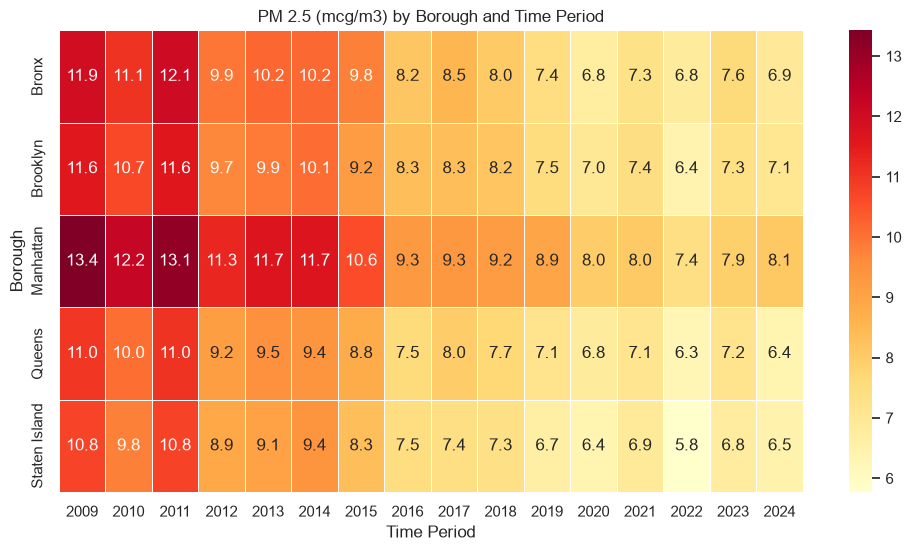

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Filter to one pollutant first (mixing units, like PM2.5 and NO2, on one heatmap
# would be misleading — same reason as the line chart earlier)
pm25 = new_table[new_table['Name'] == 'Fine particles (PM 2.5)']

# Pivot: rows = Borough, columns = Time Period, values = Data Value
air_quality = pm25.pivot_table(index='Borough', columns='Time Period', values='Data Value')

# Draw the heatmap
f, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(air_quality, annot=True, fmt=".1f", linewidths=.5, cmap='YlOrRd', ax=ax)
ax.set_title('PM 2.5 (mcg/m3) by Borough and Time Period')
plt.show()

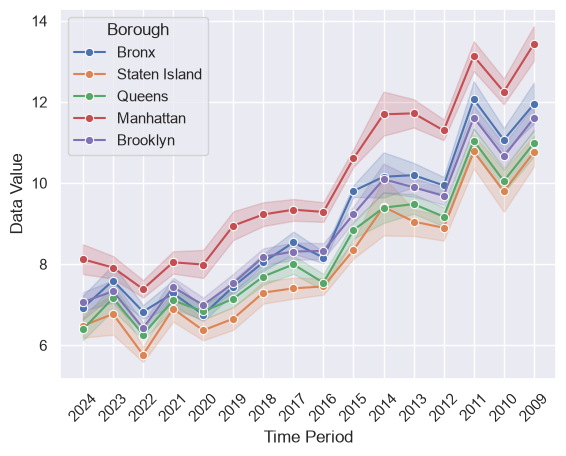

In [56]:
sns.lineplot(data=new_table[new_table['Name']=='Fine particles (PM 2.5)'], 
             x='Time Period', y='Data Value', hue='Borough', marker='o')
plt.xticks(rotation=45)
plt.show()

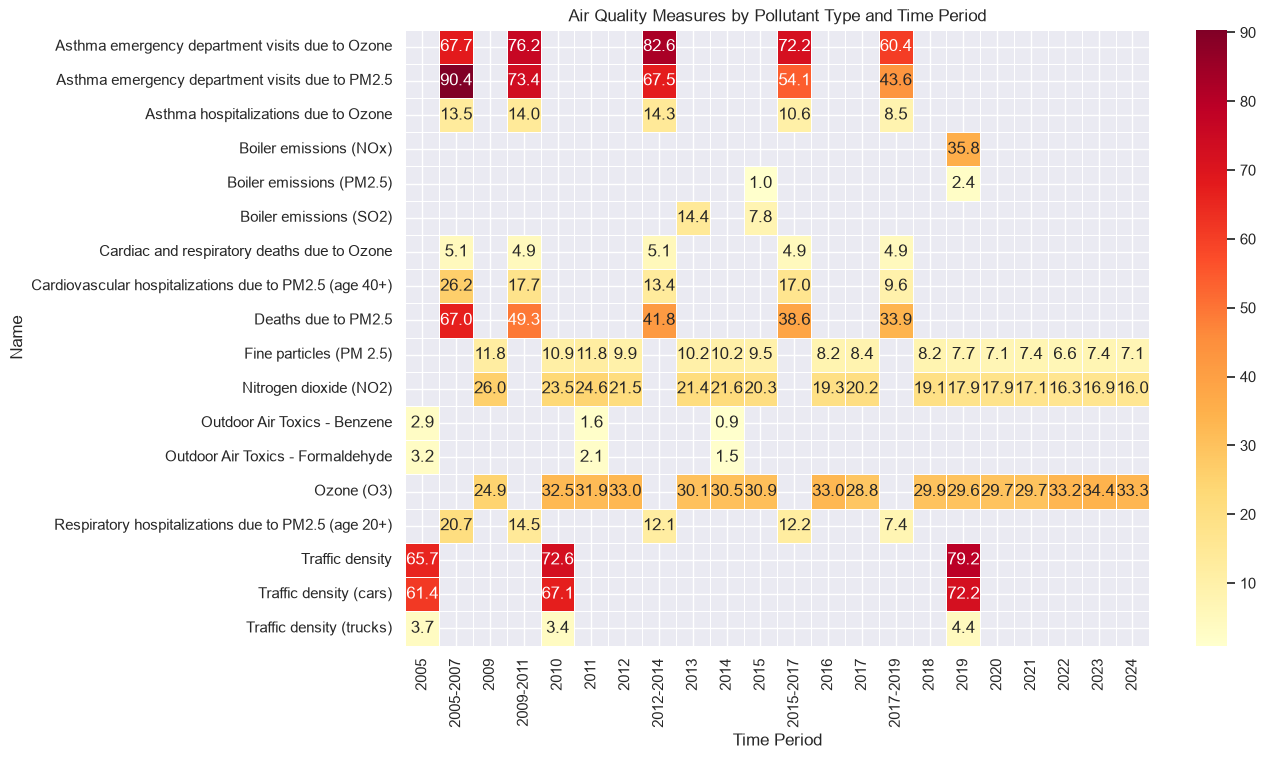

In [67]:
sns.set_theme()

air_quality = new_table.pivot_table(index='Name', columns='Time Period', values='Data Value')

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(air_quality, annot=True, fmt=".1f", linewidths=.5, cmap='YlOrRd', ax=ax)
ax.set_title('Air Quality Measures by Pollutant Type and Time Period')
plt.show()